In [1]:
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import copy
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

import matplotlib.pyplot as plt

In [6]:
def pad_matrix(G, max_n_samples=50, max_snps=200):
    n, s = G.shape
    out = np.zeros((max_n_samples, max_snps), dtype=np.float32)

    n_use = min(n, max_n_samples)
    s_use = min(s, max_snps)

    out[:n_use, :s_use] = G[:n_use, :s_use]
    return out

In [14]:
def evaluate_model(model, loader, device):
    model.eval()
    ys, preds = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)

            ys.append(y_batch.cpu().numpy())
            preds.append(pred.cpu().numpy())

    y_true = np.vstack(ys).ravel()
    y_pred = np.vstack(preds).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "y_true": y_true,
        "y_pred": y_pred
    }


def train_mlp(model, train_loader, val_loader, device, lr=1e-3, epochs=50):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_rmse = float("inf")
    best_state = None

    train_losses = []
    val_rmses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(X_batch)

        train_loss = running_loss / len(train_loader.dataset)
        val_metrics = evaluate_model(model, val_loader, device)

        train_losses.append(train_loss)
        val_rmses.append(val_metrics["rmse"])

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val RMSE: {val_metrics['rmse']:.6f} | "
            f"Val Corr: {val_metrics['corr']:.4f}"
        )

        if val_metrics["rmse"] < best_val_rmse:
            best_val_rmse = val_metrics["rmse"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return train_losses, val_rmses

In [15]:
with open("simulated_snp_dataset.pkl", "rb") as f:
    dataset = pickle.load(f)
    
num_snps_list = [item["X"].shape[1] for item in dataset]
print(np.percentile(num_snps_list, [50, 75, 90, 95, 99]))

[ 1.  2.  4.  6. 13.]


In [16]:
X_mats = np.stack([
    pad_matrix(item["X"], max_n_samples=50, max_snps=200)
    for item in dataset
])

y = np.array([item["alpha"] for item in dataset], dtype=np.float32)

# add channel dimension
X_mats = X_mats[:, None, :, :]   # shape: (N, 1, 50, 200)

print(X_mats.shape, y.shape)

(20000, 1, 50, 200) (20000,)


In [17]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_mats, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=42
)

In [18]:
class MatrixDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = MatrixDataset(X_train, y_train)
val_ds = MatrixDataset(X_val, y_val)
test_ds = MatrixDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

In [19]:
class SNPMatrixCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 6 * 25, 128),   # for input (1,50,200)
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
cnn_model = SNPMatrixCNN().to(device)
train_losses, val_rmses = train_mlp(
    cnn_model, train_loader, val_loader, device, lr=1e-3, epochs=30
)

cnn_test_metrics = evaluate_model(cnn_model, test_loader, device)
print("\nCNN Test Performance")
print(cnn_test_metrics["rmse"], cnn_test_metrics["mae"], cnn_test_metrics["r2"], cnn_test_metrics["corr"])

cuda
Epoch 001 | Train Loss: 0.000264 | Val RMSE: 0.012411 | Val Corr: 0.5413
Epoch 002 | Train Loss: 0.000170 | Val RMSE: 0.012474 | Val Corr: 0.5442
Epoch 003 | Train Loss: 0.000158 | Val RMSE: 0.012251 | Val Corr: 0.5470
Epoch 004 | Train Loss: 0.000155 | Val RMSE: 0.012223 | Val Corr: 0.5469
Epoch 005 | Train Loss: 0.000152 | Val RMSE: 0.012204 | Val Corr: 0.5462
Epoch 006 | Train Loss: 0.000152 | Val RMSE: 0.012668 | Val Corr: 0.5471
Epoch 007 | Train Loss: 0.000151 | Val RMSE: 0.012235 | Val Corr: 0.5422
Epoch 008 | Train Loss: 0.000152 | Val RMSE: 0.012306 | Val Corr: 0.5488
Epoch 009 | Train Loss: 0.000150 | Val RMSE: 0.012258 | Val Corr: 0.5468
Epoch 010 | Train Loss: 0.000150 | Val RMSE: 0.012339 | Val Corr: 0.5479
Epoch 011 | Train Loss: 0.000149 | Val RMSE: 0.012399 | Val Corr: 0.5401
Epoch 012 | Train Loss: 0.000151 | Val RMSE: 0.012333 | Val Corr: 0.5445
Epoch 013 | Train Loss: 0.000150 | Val RMSE: 0.012254 | Val Corr: 0.5459
Epoch 014 | Train Loss: 0.000149 | Val RMSE: 0

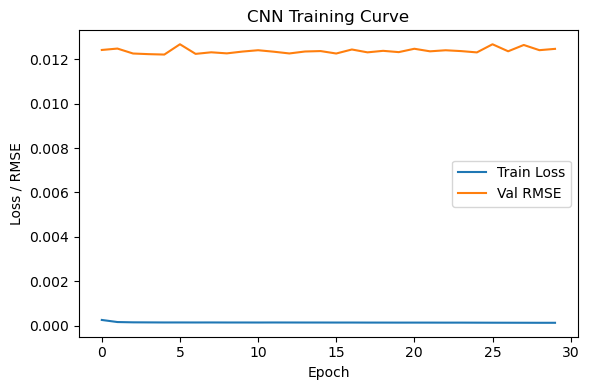

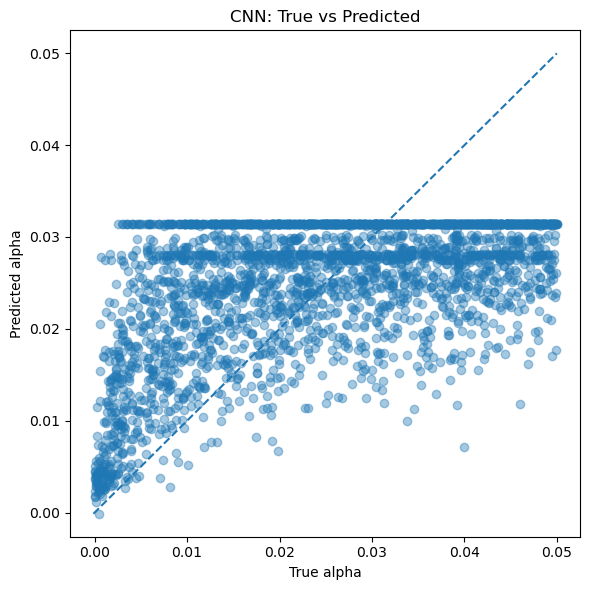

In [21]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_rmses, label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("Loss / RMSE")
plt.title("CNN Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(cnn_test_metrics["y_true"], cnn_test_metrics["y_pred"], alpha=0.4)
mn = min(cnn_test_metrics["y_true"].min(), cnn_test_metrics["y_pred"].min())
mx = max(cnn_test_metrics["y_true"].max(), cnn_test_metrics["y_pred"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("True alpha")
plt.ylabel("Predicted alpha")
plt.title("CNN: True vs Predicted")
plt.tight_layout()
plt.show()